# Flight Final Descent Anomaly Detection and Classification
Contributors: Elan Wilkinson, Melissa Short, Nicholas Short
----


---

## Set Up Necessary Dependencies
### Install Required Libraries

In [ ]:
!pip install --disable-pip-version-check -q pip --upgrade > /dev/null
!pip install --disable-pip-version-check -q wrapt --upgrade > /dev/null

!pip install --disable-pip-version-check -q awscli boto3

!pip install --disable-pip-version-check -q sagemaker
!pip install --disable-pip-version-check -q smdebug
!pip install --disable-pip-version-check -q sagemaker-experiments

!pip install --disable-pip-version-check -q PyAthena

!pip install --disable-pip-version-check -q awswrangler

!conda install -y zip

!pip install --upgrade tensorflow

#### Import Necessary Libraries

In [2]:
import random
import pandas as pd
import pickle
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import os
from tensorflow.keras.utils import to_categorical
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import boto3
import sagemaker
from pyathena import connect
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
import tarfile
from sklearn.metrics import classification_report

### Import Training Data from CSV

#### If needing to connect to drive from Google Colab

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Create DataFrame from CSV

In [4]:
#df = pd.read_csv("/home/sagemaker-user/FlightFinalApproachAnomalyDetection/training_flight_data.csv")
df = pd.read_csv("/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/training_flight_data.csv")

#### Set Column Names

In [5]:
df.columns = ['sample_id', 'time_step', 'aileron_pos_lh_deg', 'aileron_pos_rh_deg', 'corrected_angle_of_attack_deg', 'baro_correct_alt_lsp_ft', 'computed_airspeed_lsp_knots',
    'selected_course_deg', 'drift_angle_deg', 'elevator_pos_left_deg', 'te_flap_pos_disc', 'glideslope_dev_perc', 'selected_heading_deg', 'localizer_dev_perc', 'core_speed_avg_perc',
    'total_pressure_lsp_millibar', 'pitch_angle_lsp_deg', 'roll_angle_lsp_deg', 'rudder_pos_deg', 'true_heading_lsp_deg', 'vertical_accel_g', 'wind_speed_knots', 'label']

#### Get Float Columns

In [6]:
float_columns = [col for col in df.columns if col not in ['sample_id', 'time_step', 'label'] and df[col].dtype == 'float64']


### Incorporate Arrival Airport into Data
#### Bring in data from CSV

In [7]:
sample_ids = df['sample_id'].unique()
flight_metadata_df = pd.read_csv("/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/DASHlink_full_fourclass_raw_meta (1).csv")
train_flight_metadata_train = flight_metadata_df[flight_metadata_df['data_instance'].isin(sample_ids)]

#### Filter down to just arrival airport and associated sample ID

In [8]:
arrival_and_samp = train_flight_metadata_train.copy()
arrival_and_samp = arrival_and_samp[['data_instance', 'arrival_airport']]
arrival_and_samp.columns = ['sample_id', 'arrival_airport']
arrival_and_samp['arrival_airport_catenc'], arrival_airport_mapping = pd.factorize(arrival_and_samp['arrival_airport'])
arrival_and_samp.drop(columns=['arrival_airport'], inplace=True)
arrival_and_samp['arrival_airport_catenc'] = arrival_and_samp['arrival_airport_catenc'].astype(float)
arrival_and_samp.head()

,sample_id,arrival_airport_catenc
0,0,0.0
2,2,0.0
3,3,1.0
5,5,0.0
6,6,2.0


#### Balance Classes in Training Data

In [9]:
num_unique = (int)(len((df[df['label'] == 3]))/160)
rand_zeroes = df[df['label'] == 0]['sample_id'].unique()
unique_zeros = random.choices(rand_zeroes, k=num_unique)
rand_ones = df[df['label'] == 1]['sample_id'].unique()
unique_ones = random.choices(rand_ones, k=num_unique)
rand_twos = df[df['label'] == 2]['sample_id'].unique()
unique_twos = random.choices(rand_twos, k=num_unique)
sampleids_to_keep = df[df['label'] == 3]['sample_id'].unique().tolist()
sampleids_to_keep.extend(unique_ones)
sampleids_to_keep.extend(unique_twos)
sampleids_to_keep.extend(unique_zeros)

training_df = df[df['sample_id'].isin(sampleids_to_keep)]

#### Append Categorically Encoded Arrival

In [10]:
training_df = training_df.merge(arrival_and_samp, on='sample_id', how='left')

#### Data Scaling

In [15]:
df_scaled = training_df.copy()
scalers = []

scalers_directory = os.path.join(os.getcwd(), 'scalers')
if not os.path.exists(scalers_directory):
    os.makedirs(scalers_directory)

for col in float_columns:
  new_scaler = MinMaxScaler()
  scaler_name = os.path.join(scalers_directory,f"{col}_scaler.pkl")
  df_scaled[col] = new_scaler.fit_transform(df_scaled[[col]])
  scalers.append(new_scaler)
  with open(scaler_name, 'wb') as scaler_file:
    pickle.dump(new_scaler, scaler_file)

train_x = df_scaled.copy()
train_x = train_x.drop(columns=['label','sample_id'])
train_y = df_scaled['label']

##### Open Scalers

In [14]:
scalers = []

for col in float_columns:
  scaler_name = os.path.join(scalers_directory,f"{col}_scaler.pkl")

  with open(scaler_name, 'rb') as file:
      loaded_scaler = pickle.load(file)
      #df_scaled[col] = loaded_scaler.transform(df_scaled[[col]])
      scalers.append(loaded_scaler)

### Import and Prepare Validation Data
---

In [16]:
valid_df = pd.read_csv("/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/valid_flight_data.csv")
valid_df.columns = ['sample_id', 'time_step', 'aileron_pos_lh_deg', 'aileron_pos_rh_deg', 'corrected_angle_of_attack_deg',
'baro_correct_alt_lsp_ft', 'computed_airspeed_lsp_knots',
    'selected_course_deg', 'drift_angle_deg', 'elevator_pos_left_deg', 'te_flap_pos_disc', 'glideslope_dev_perc', 'selected_heading_deg', 'localizer_dev_perc', 'core_speed_avg_perc',
    'total_pressure_lsp_millibar', 'pitch_angle_lsp_deg', 'roll_angle_lsp_deg', 'rudder_pos_deg', 'true_heading_lsp_deg', 'vertical_accel_g', 'wind_speed_knots', 'label']

In [17]:
valid_ids = valid_df['sample_id'].unique()
print(valid_ids)
flight_metadata_valid = flight_metadata_df[flight_metadata_df['data_instance'].isin(valid_ids)]
flight_metadata_valid.head()
arrival_and_samp = flight_metadata_valid.copy()
arrival_and_samp = arrival_and_samp[['data_instance', 'arrival_airport']]
arrival_and_samp.columns = ['sample_id', 'arrival_airport']
arrival_and_samp
valid_df = valid_df.merge(arrival_and_samp, on='sample_id', how='left')
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport'].map(dict(enumerate(arrival_airport_mapping)))
valid_df.tail()

[   15    20    21 ... 99806 99809 99810]


,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport,arrival_airport_catenc
1629275,99810,155,83.73661,69.49784,1.817228,616.34467,125.377450,-145.0185,-0.701310,-1.822781,...,1004.52594,3.309562,1.056722,-0.471746,-151.14806,0.991589,1.355669,3.0,KDTW,NaN
1629276,99810,156,82.55005,74.89876,1.139800,614.71620,124.622140,-145.0185,-1.029845,-1.679573,...,1004.09440,3.003177,1.689748,-0.586573,-150.18675,1.009410,2.146087,3.0,KDTW,NaN
1629277,99810,157,79.89050,77.19005,1.652527,613.72650,123.039150,-145.0185,-1.113408,0.018440,...,1003.51263,3.108795,0.979927,-0.487490,-150.80489,0.973769,2.340231,3.0,KDTW,NaN
1629278,99810,158,78.21295,73.48715,1.715791,616.63040,121.915794,-145.0185,-1.802660,5.664848,...,1002.90576,2.889801,0.005120,-0.576744,-149.50856,1.035906,3.913119,3.0,KDTW,NaN
1629279,99810,159,73.46670,70.37753,0.894369,614.58470,119.480550,-145.0185,-1.632066,3.046223,...,1001.97240,2.361194,-0.899853,-0.491064,-150.44374,0.995308,3.952124,3.0,KDTW,NaN


In [18]:
arrival_airport_mapping_dict = {airport: idx for idx, airport in enumerate(arrival_airport_mapping)}
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport'].map(arrival_airport_mapping_dict)
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport_catenc'].astype(float)
valid_df.drop(columns=['arrival_airport'], inplace=True)
valid_df.head()

,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport_catenc
0,15,0,80.606540,81.54761,-5.420757,2468.7761,180.01007,34.98022,3.319528,-3.500336,...,61.523205,978.03235,-1.985861,-1.344085,-2.817326,24.699790,1.015660,14.561880,0.0,5.0
1,15,1,79.849594,80.42242,-5.116660,2453.4820,178.55055,34.98022,3.403981,-3.561710,...,61.480885,977.95966,-1.719461,-1.292599,1.381010,24.573366,1.040051,14.044608,0.0,5.0
2,15,2,81.506690,82.01814,-4.978041,2441.3076,179.56377,34.98022,3.030978,-3.459419,...,61.483383,978.70500,-1.735226,0.008662,-3.048076,24.782553,1.032340,14.027080,0.0,5.0
3,15,3,81.813560,82.79555,-5.357613,2426.1600,177.57582,34.98022,3.490517,-3.664001,...,61.506645,978.21350,-1.802503,1.149909,1.843847,24.539455,1.000205,13.811078,0.0,5.0
4,15,4,82.652336,83.10242,-6.084550,2411.2341,179.69500,34.98022,3.546878,-3.664001,...,61.506870,980.06050,-2.078131,0.974984,-2.606024,24.573948,0.967859,15.460607,0.0,5.0


In [19]:
valid_scaled = valid_df.copy()
for i in range (0,len(float_columns)):
  valid_scaled[float_columns[i]] = scalers[i].transform(valid_scaled[[float_columns[i]]])

In [20]:
valid_x = valid_scaled.copy()
valid_x = valid_x.drop(columns=['label','sample_id'])
valid_y = valid_scaled['label']

### Reshape Data for Modeling
---

In [21]:
def reshape_data(x_data,y_data):
  num_samples = len(x_data) // 160
  num_features = x_data.shape[1]
  y_data_ = []
  for i in range(0,len(y_data),160):
    y_data_.append(y_data[i])

  x_data = x_data.values.reshape((num_samples, 160, num_features))
  y_data = np.array(y_data_)
  return x_data,y_data

In [22]:
train_x, train_y = reshape_data(train_x,train_y)
valid_x, valid_y = reshape_data(valid_x,valid_y)

#### Need Categorical Y for LSTM

In [23]:
train_y = to_categorical(train_y)
valid_y = to_categorical(valid_y)

## Data Lake and Feature Store
---


In [ ]:
session = boto3.session.Session()
region = session.region_name
sagemaker_session = sagemaker.Session()
bucket = 'flightfinalapproachanomalydetection' # bucket name here

s3 = boto3.Session().client(service_name="s3", region_name=region)

print("Bucket name: {}".format(bucket))

In [ ]:
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client(service_name="sagemaker", region_name=region)

In [ ]:
from IPython.core.display import display, HTML

display(
    HTML(
        '<b>Review <a target="blank" href="https://s3.console.aws.amazon.com/s3/buckets/flightfinalapproachanomalydetection/?region={}&tab=overview">S3 Bucket</a></b>'.format(
            region, account_id, region
        )
    )
)

### Create Athena Database Scheme


In [ ]:
database_name = "flightdata_db"
s3_staging_dir = "s3://{0}/athena/staging".format(bucket)
conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)

statement = "CREATE DATABASE IF NOT EXISTS {}".format(database_name)
print(statement)

In [ ]:
cursor = conn.cursor()
cursor.execute(statement)
print("Database created successfully")

In [ ]:
statement = "SHOW DATABASES"

df_show = pd.read_sql(statement, conn)
df_show.head(5)

### Register CSV with Athena

In [ ]:
drop_statement = "DROP TABLE flightdata_db.flight_csv_data"
cursor = conn.cursor()
cursor.execute(drop_statement)
print("Table dropped successfully.")

In [ ]:
statement = """CREATE EXTERNAL TABLE IF NOT EXISTS flightdata_db.flight_csv_data (
        sample_id int,
        timestep int,
        aileron_pos_lh_deg float,
        aileron_pos_rh_deg float,
        corrected_angle_of_attack_deg float,
        baro_correct_alt_lsp_ft float,
        computed_airspeed_lsp_knots float,
        selected_course_deg float,
        drift_angle_deg float,
        elevator_pos_left_deg float,
        te_flap_pos_disc float,
        glideslope_dev_perc float,
        selected_heading_deg float,
        localizer_dev_perc float,
        core_speed_avg_perc float,
        total_pressure_lsp_millibar float,
        pitch_angle_lsp_deg float,
        roll_angle_lsp_deg float,
        rudder_pos_deg float,
        true_heading_lsp_deg float,
        vertical_accel_g float,
        wind_speed_knots float,
        label int
)
STORED AS TEXTFILE
LOCATION 's3://flightfinalapproachanomalydetection/csv/'
TBLPROPERTIES (
    'skip.header.line.count'='1',
    'field.delim'=',',
    'compressionType'='none'
)"""

## Modeling
### LSTM Model

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,532 (88.02 KB)

 Trainable params: 22,532 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.2544 - loss: 1.4012 - val_accuracy: 0.2814 - val_loss: nan
Epoch 2/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.2749 - loss: 1.3801 - val_accuracy: 0.0114 - val_loss: nan
Epoch 3/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.3093 - loss: 1.3752 - val_accuracy: 0.5411 - val_loss: nan
Epoch 4/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.3908 - loss: 1.3348 - val_accuracy: 0.7372 - val_loss: nan
Epoch 5/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.3761 - loss: 1.3307 - val_accuracy: 0.8542 - val_loss: nan
Epoch 6/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.3052 - loss: 1.3575 - val_accuracy: 0.7262 - val_loss: nan
Epoch 7/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.4037 - loss: 1.3355 - val_accuracy: 0.6069 - val_loss: nan
Epoch 8/350
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.3862 - loss: 1.3170 - val_accuracy: 0.6128 - v

Text(0.5, 1.0, 'model loss')

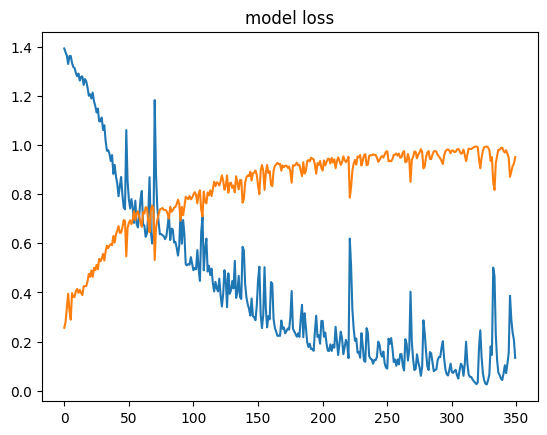

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

num_features = train_x.shape[2]

m_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(160, num_features)))
lstm_model.add(Dense(4, activation='sigmoid'))
lstm_model.compile(optimizer=m_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print(lstm_model.summary())
lstm_hist = lstm_model.fit(train_x, train_y, epochs=350, batch_size=64, validation_data=(valid_x, valid_y))

# plot hist
import matplotlib.pyplot as plt
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.title('model loss')

Text(0.5, 1.0, 'model loss')

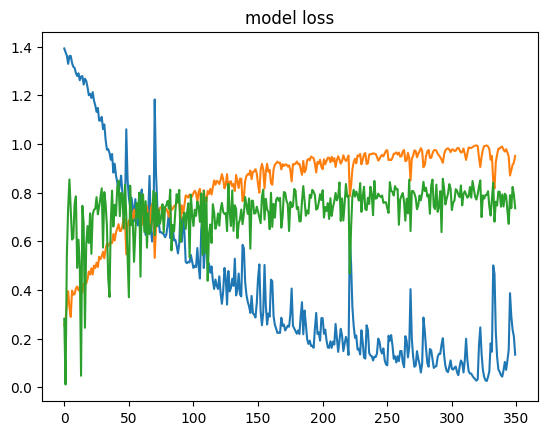

In [ ]:
# plot hist
import matplotlib.pyplot as plt
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.plot(lstm_hist.history['val_accuracy'])
plt.title('model loss')

### Save Model

In [ ]:
model_dir = "/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/LSTMmodel"
os.makedirs(model_dir, exist_ok=True)

model.export(model_dir)

tarball_name = "lstm_model.tar.gz"
with tarfile.open(tarball_name, "w:gz") as tar:
    tar.add(model_dir, arcname=os.path.basename(model_dir))

print(f"Model saved as {tarball_name}")

Saved artifact at '/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/LSTMmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 22), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139820204656784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204658896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model saved as lstm_model.tar.gz


### Classification Report

In [ ]:
valid_y_argmaxed = valid_y.argmax(axis=1)
print(classification_report(valid_y_argmaxed, preds.argmax(axis=1)))
print(preds)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      9146
           1       0.38      0.58      0.46       715
           2       0.19      0.69      0.29       225
           3       0.47      0.97      0.63        97

    accuracy                           0.83     10183
   macro avg       0.50      0.77      0.57     10183
weighted avg       0.91      0.83      0.86     10183

[[0.9692502  0.67852646 0.02187795 0.03043036]
 [0.9923308  0.02723334 0.00434992 0.88280094]
 [0.9900017  0.19605248 0.02492564 0.11360192]
 ...
 [0.0863151  0.5634494  0.00118054 0.9997788 ]
 [0.03979751 0.51264393 0.00385703 0.9998391 ]
 [0.93349063 0.04790827 0.00583803 0.98676866]]
